# Análisis Exploratorio — CommonLit: Evaluar resúmenes de estudiantes

Predicción de las puntuaciones `content` y `wording` de resúmenes escritos por estudiantes.
Competencia: https://www.kaggle.com/competitions/commonlit-evaluate-student-summaries/overview



El objetivo es predecir dos puntuaciones que un evaluador experto asigna al resumen de un estudiante:

- **content**: qué tan bien el resumen captura y relaciona las ideas principales del texto fuente.
- **wording**: claridad, precisión y calidad objetiva de la redacción (vocabulario y sintaxis propios).

La métrica de la competencia es MCRMSE.

Solo hay 4 textos fuente (*prompts*) en entrenamiento y el test real usa prompts distintos, así que el problema central es generalizar a prompts no vistos. Por eso la validación debe hacerse por grupo (`GroupKFold` sobre `prompt_id`).


In [2]:
import sys, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent / 'src'))
import eda_utils as eu

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')

DATA_DIR = Path.cwd().parent / 'data'
FIG_DIR = Path.cwd().parent / 'figuras'
FIG_DIR.mkdir(exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'{name}.png', dpi=120, bbox_inches='tight')

print('Archivos en data/:', sorted(p.name for p in DATA_DIR.glob('*')))

Archivos en data/: ['.gitkeep', 'commonlit-evaluate-student-summaries.zip', 'features_train.parquet', 'prompts_test.csv', 'prompts_train.csv', 'sample_submission.csv', 'summaries_test.csv', 'summaries_train.csv']


## Carga de datos

In [3]:
summaries_train = pd.read_csv(DATA_DIR / 'summaries_train.csv')
prompts_train = pd.read_csv(DATA_DIR / 'prompts_train.csv')
summaries_test = pd.read_csv(DATA_DIR / 'summaries_test.csv')
prompts_test = pd.read_csv(DATA_DIR / 'prompts_test.csv')

print('summaries_train:', summaries_train.shape)
print('prompts_train  :', prompts_train.shape)
print('summaries_test :', summaries_test.shape)
print('prompts_test   :', prompts_test.shape)
summaries_train.head()

summaries_train: (7165, 5)
prompts_train  : (4, 4)
summaries_test : (4, 3)
prompts_test   : (2, 4)


,student_id,prompt_id,text,content,wording
0,000e8c3c7ddb,814d6b,The third wave was an experimentto see how peo...,0.205683,0.380538
1,0020ae56ffbf,ebad26,They would rub it up with soda to make the sme...,-0.548304,0.506755
2,004e978e639e,3b9047,"In Egypt, there were many occupations and soci...",3.128928,4.231226
3,005ab0199905,3b9047,The highest class was Pharaohs these people we...,-0.210614,-0.471415
4,0070c9e7af47,814d6b,The Third Wave developed rapidly because the ...,3.272894,3.219757


## Variables y observaciones

Número de filas y columnas de cada tabla, tipo de cada variable, faltantes y cardinalidad.

In [4]:
def describe_schema(df, name):
    info = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'n_missing': df.isna().sum(),
        'pct_missing': (df.isna().mean() * 100).round(2),
        'n_unique': df.nunique(),
        'ejemplo': [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
    })
    print(f'== {name} ==  filas={len(df)}  columnas={df.shape[1]}')
    return info

describe_schema(summaries_train, 'summaries_train')

== summaries_train ==  filas=7165  columnas=5


,dtype,n_missing,pct_missing,n_unique,ejemplo
student_id,object,0,0.0,7165,000e8c3c7ddb
prompt_id,object,0,0.0,4,814d6b
text,object,0,0.0,7165,The third wave was an experimentto see how peo...
content,float64,0,0.0,1134,0.205683
wording,float64,0,0.0,1134,0.380538


In [5]:
describe_schema(prompts_train, 'prompts_train')

== prompts_train ==  filas=4  columnas=4


,dtype,n_missing,pct_missing,n_unique,ejemplo
prompt_id,object,0,0.0,4,39c16e
prompt_question,object,0,0.0,4,Summarize at least 3 elements of an ideal trag...
prompt_title,object,0,0.0,4,On Tragedy
prompt_text,object,0,0.0,4,Chapter 13 \r\nAs the sequel to what has alrea...


In [6]:
# Textos fuente: consigna y longitud de cada prompt
prompts_train.assign(
    palabras_texto_fuente=prompts_train['prompt_text'].map(lambda t: len(eu.tokenize_words(t))),
    palabras_consigna=prompts_train['prompt_question'].map(lambda t: len(eu.tokenize_words(str(t)))),
)[['prompt_id', 'prompt_title', 'prompt_question', 'palabras_texto_fuente', 'palabras_consigna']]

,prompt_id,prompt_title,prompt_question,palabras_texto_fuente,palabras_consigna
0,39c16e,On Tragedy,Summarize at least 3 elements of an ideal trag...,599,12
1,3b9047,Egyptian Social Structure,"In complete sentences, summarize the structure...",555,27
2,814d6b,The Third Wave,Summarize how the Third Wave developed over su...,597,19
3,ebad26,Excerpt from The Jungle,Summarize the various ways the factory would u...,976,18


In [7]:
# Duplicados y consistencia de llaves
print('student_id duplicados:', summaries_train['student_id'].duplicated().sum())
print('prompt_id en summaries no presentes en prompts:',
      set(summaries_train['prompt_id']) - set(prompts_train['prompt_id']))
print('resúmenes por prompt:')
print(summaries_train['prompt_id'].value_counts())

student_id duplicados: 0
prompt_id en summaries no presentes en prompts: set()
resúmenes por prompt:
prompt_id
39c16e    2057
3b9047    2009
ebad26    1996
814d6b    1103
Name: count, dtype: int64


**Observaciones de la descripción de los datos**

- `summaries_train` tiene 7 165 filas y 5 columnas; prompts_train tiene 4 filas y 4 columnas. El test.csv visible es solo un formato.
- Tipos: `student_id` y `prompt_id` son texto (identificador y categórica); `text` es texto libre; `content` y `wording` son numéricas continuas.
- `student_id` es único, no hay duplicados de `text`, y todos los `prompt_id` de los resúmenes existen en `prompts_train`.
- No hay valores faltantes en ninguna de las dos tablas.
- Los 4 textos fuente son de temas distintos (tragedia de Aristóteles, Antiguo Egipto, *The Third Wave*, *The Jungle*) y varían en longitud.

## Limpieza

Se normalizan espacios, saltos de línea y caracteres de control. Se conserva la puntuación y las mayúsculas porque son señales de calidad de redacción. Se revisan textos vacíos o muy cortos y los valores faltantes en `content` y `wording`. 

Después se une cada resumen con su texto fuente (`merge` por `prompt_id`) y se calculan las características de texto sobre esa tabla.

In [8]:
df = summaries_train.copy()
df['text_raw_len'] = df['text'].str.len()
df['text'] = df['text'].map(eu.basic_clean)
df['text_clean_len'] = df['text'].str.len()

print('Textos vacíos tras limpieza:', (df['text'].str.len() == 0).sum())
print('Textos con < 5 palabras   :', (df['text'].str.split().map(len) < 5).sum())
print('Faltantes en objetivos    :\n', df[['content', 'wording']].isna().sum())
df[['text_raw_len', 'text_clean_len']].describe()

Textos vacíos tras limpieza: 0
Textos con < 5 palabras   : 0
Faltantes en objetivos    :
 content    0
wording    0
dtype: int64


,text_raw_len,text_clean_len
count,7165.000000,7165.000000
mean,418.776971,417.424983
std,307.833685,307.163206
min,114.000000,114.000000
25%,216.000000,215.000000
50%,320.000000,319.000000
75%,513.000000,511.000000
max,3940.000000,3936.000000


In [9]:
# Revisión de longitudes extremas: los resúmenes más cortos y más largos
wc = df['text'].str.split().map(len)
print('rango de palabras por resumen:', wc.min(), '-', wc.max())
print('\n--- 3 más cortos ---')
for t in df.loc[wc.nsmallest(3).index, 'text']:
    print(repr(t[:300]))
print('\n--- 1 más largo ---')
print(repr(df.loc[wc.idxmax(), 'text'][:400]), '...')

rango de palabras por resumen: 22 - 647

--- 3 más cortos ---
"A tragedy should have a comples plot, imitate actions that bring people to pity or fear, and shoudn't be a run-of-the-mill plot"
'Meat workers would prepare rotten and diseased meat with better meats.Pork fat,beef,and canned chicken would be chopped up and used to make sausage.'
"Whenever the meat was spoiled, and couldn't be used for anything, they would can it, or chop it into sausage. (Paragraph 1; lines 4-7)"

--- 1 más largo ---
'The base starts with farmers and slaves. The economical positions rise as they go up. At the very top point of the pyramid are the gods. Here is the order from greatest to least: Egyptian Gods/Pharaohs, nobles/priests, soldiers, craftmen/traders, and lastly farmers/slaves. The gods are at the highest position in status. They have the right to overpower everyone. Also, since everyone praises them t' ...


In [10]:
# Construcción de la tabla de características (resumen + prompt)
feat = eu.build_feature_frame(df, prompts_train)
print(feat.shape)
feat[eu.NUMERIC_FEATURES + eu.TARGETS].head()

(7165, 31)


,char_count,word_count,sentence_count,unique_word_count,type_token_ratio,avg_word_length,avg_sentence_length_words,stopword_ratio,punct_per_word,uppercase_ratio,digit_ratio,exclamation_count,question_count,comma_count,jaccard_unigram,prop_words_in_source,bigram_overlap_ratio,trigram_overlap_ratio,new_word_ratio,prompt_word_count,summary_source_word_ratio,content,wording
0,346.0,61.0,4.0,49.0,0.803279,4.639344,15.250000,0.409836,0.049180,0.011561,0.000000,0.0,0.0,0.0,0.037975,0.281250,0.028571,0.000000,0.718750,597,0.102178,0.205683,0.380538
1,244.0,52.0,2.0,35.0,0.673077,3.673077,26.000000,0.596154,0.038462,0.008197,0.000000,0.0,0.0,0.0,0.045603,0.875000,0.200000,0.052632,0.125000,976,0.053279,-0.548304,0.506755
2,1370.0,237.0,12.0,137.0,0.578059,4.645570,19.750000,0.417722,0.160338,0.013869,0.000000,0.0,0.0,16.0,0.197232,0.532710,0.116788,0.029412,0.467290,555,0.427027,3.128928,4.231226
3,157.0,27.0,5.0,20.0,0.740741,4.629630,5.400000,0.444444,0.222222,0.025478,0.012739,0.0,0.0,0.0,0.032787,0.615385,0.214286,0.153846,0.384615,555,0.048649,-0.210614,-0.471415
4,1222.0,200.0,14.0,124.0,0.620000,4.920000,14.285714,0.455000,0.150000,0.022913,0.006547,1.0,0.0,5.0,0.091241,0.294118,0.074074,0.009346,0.705882,597,0.335008,3.272894,3.219757


## Análisis exploratorio

### Variables numéricas

Estadística descriptiva de las características de texto y de las dos variables objetivo: media, desviación, percentiles, asimetría y curtosis.

In [11]:
desc = feat[eu.NUMERIC_FEATURES + eu.TARGETS].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
desc['skew'] = feat[desc.index].skew()
desc['kurtosis'] = feat[desc.index].kurtosis()
desc.round(3)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,kurtosis
char_count,7165.0,417.425,307.163,114.000,132.640,151.000,215.000,319.000,511.000,1010.800,1569.800,3936.000,2.681,12.366
word_count,7165.0,74.825,53.481,22.000,26.000,28.000,39.000,58.000,92.000,178.000,273.360,659.000,2.617,11.694
sentence_count,7165.0,4.074,3.315,1.000,1.000,1.000,2.000,3.000,5.000,10.000,17.000,54.000,3.145,20.933
unique_word_count,7165.0,48.580,26.030,13.000,19.000,22.000,30.000,41.000,59.000,100.000,141.000,277.000,1.924,6.017
type_token_ratio,7165.0,0.703,0.106,0.259,0.468,0.526,0.627,0.705,0.781,0.875,0.929,1.000,-0.094,-0.387
avg_word_length,7165.0,4.439,0.388,3.071,3.630,3.824,4.167,4.433,4.696,5.077,5.420,6.464,0.239,0.230
avg_sentence_length_words,7165.0,21.772,11.410,4.625,8.207,10.125,14.200,18.750,26.500,42.000,62.000,157.000,2.760,16.323
stopword_ratio,7165.0,0.477,0.058,0.179,0.324,0.381,0.442,0.479,0.514,0.571,0.621,0.750,-0.071,0.875
punct_per_word,7165.0,0.117,0.059,0.000,0.000,0.036,0.077,0.109,0.149,0.222,0.286,0.946,1.205,6.850
uppercase_ratio,7165.0,0.012,0.008,0.000,0.000,0.000,0.007,0.011,0.015,0.024,0.036,0.174,4.504,58.249


### Variables categóricas

In [12]:
freq = feat.groupby(['prompt_id']).agg(
    n=('text', 'size'),
    prompt_title=('prompt_title', 'first'),
    content_mean=('content', 'mean'),
    wording_mean=('wording', 'mean'),
    word_count_mean=('word_count', 'mean'),
)
freq['proporcion'] = (freq['n'] / freq['n'].sum()).round(3)
freq.round(3)

,n,prompt_title,content_mean,wording_mean,word_count_mean,proporcion
prompt_id,,,,,,
39c16e,2057,On Tragedy,-0.095,-0.141,62.778,0.287
3b9047,2009,Egyptian Social Structure,0.050,-0.069,83.788,0.280
814d6b,1103,The Third Wave,0.150,0.519,72.640,0.154
ebad26,1996,Excerpt from The Jungle,-0.088,-0.299,79.426,0.279


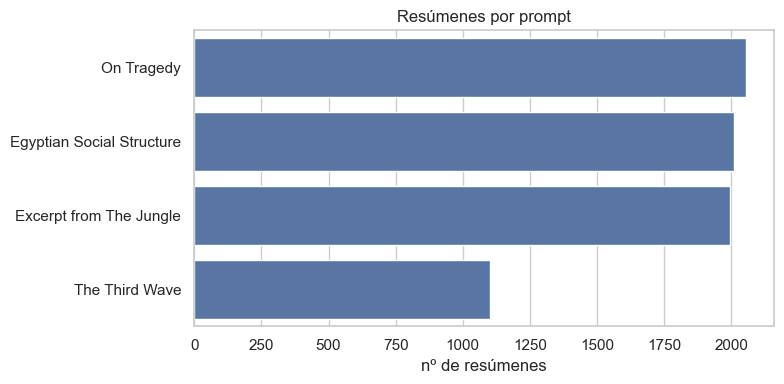

In [13]:
# Gráfico de barras: número de resúmenes por prompt
plt.figure(figsize=(8, 4))
order = feat['prompt_title'].value_counts().index
sns.countplot(data=feat, y='prompt_title', order=order)
plt.xlabel('nº de resúmenes')
plt.ylabel('')
plt.title('Resúmenes por prompt')
savefig('bar_resumenes_por_prompt')
plt.show()

### Gráficos exploratorios

#### Variables objetivo

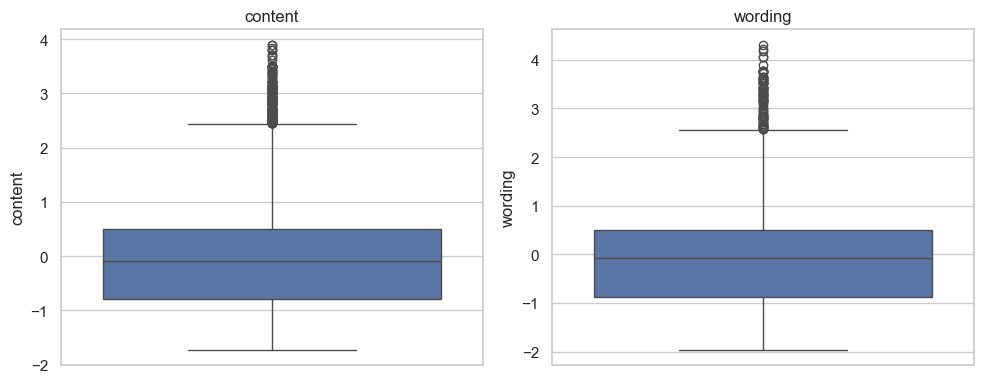

content: 170 outliers fuera de [-2.75, 2.45]
wording: 87 outliers fuera de [-2.94, 2.57]


In [14]:
# Boxplots de content y wording (detección de outliers en las variables objetivo)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, col in zip(ax, eu.TARGETS):
    sns.boxplot(y=feat[col], ax=a)
    a.set_title(col)
savefig('box_targets')
plt.show()

# Outliers de las variables objetivo por regla IQR
for col in eu.TARGETS:
    q1, q3 = feat[col].quantile(.25), feat[col].quantile(.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = ((feat[col] < lo) | (feat[col] > hi)).sum()
    print(f'{col}: {n} outliers fuera de [{lo:.2f}, {hi:.2f}]')

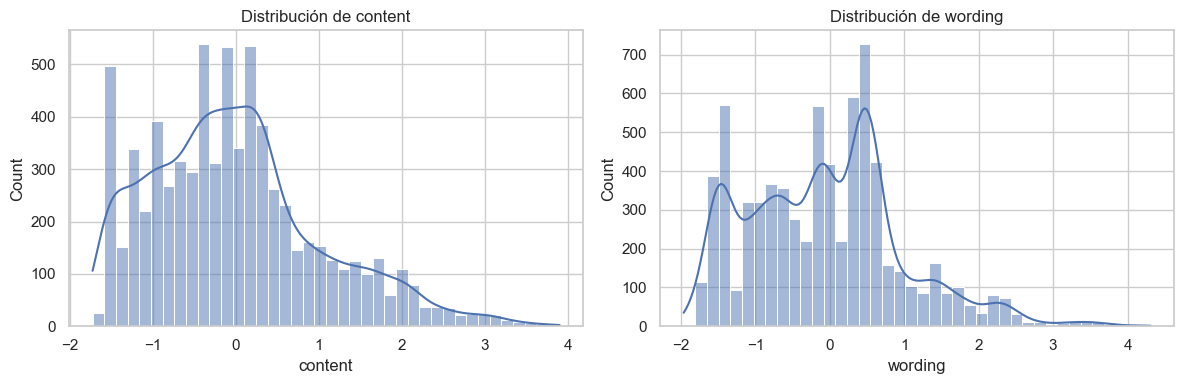

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, col in zip(ax, eu.TARGETS):
    sns.histplot(feat[col], kde=True, ax=a, bins=40)
    a.set_title(f'Distribución de {col}')
savefig('dist_targets')
plt.show()

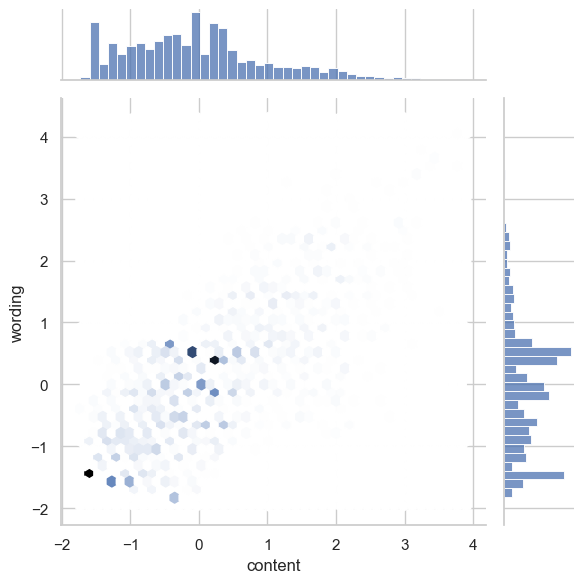

Correlación content-wording: 0.751


In [16]:
sns.jointplot(data=feat, x='content', y='wording', kind='hex', height=6)
savefig('content_vs_wording')
plt.show()
print('Correlación content-wording:', feat['content'].corr(feat['wording']).round(3))

#### Histogramas de las características

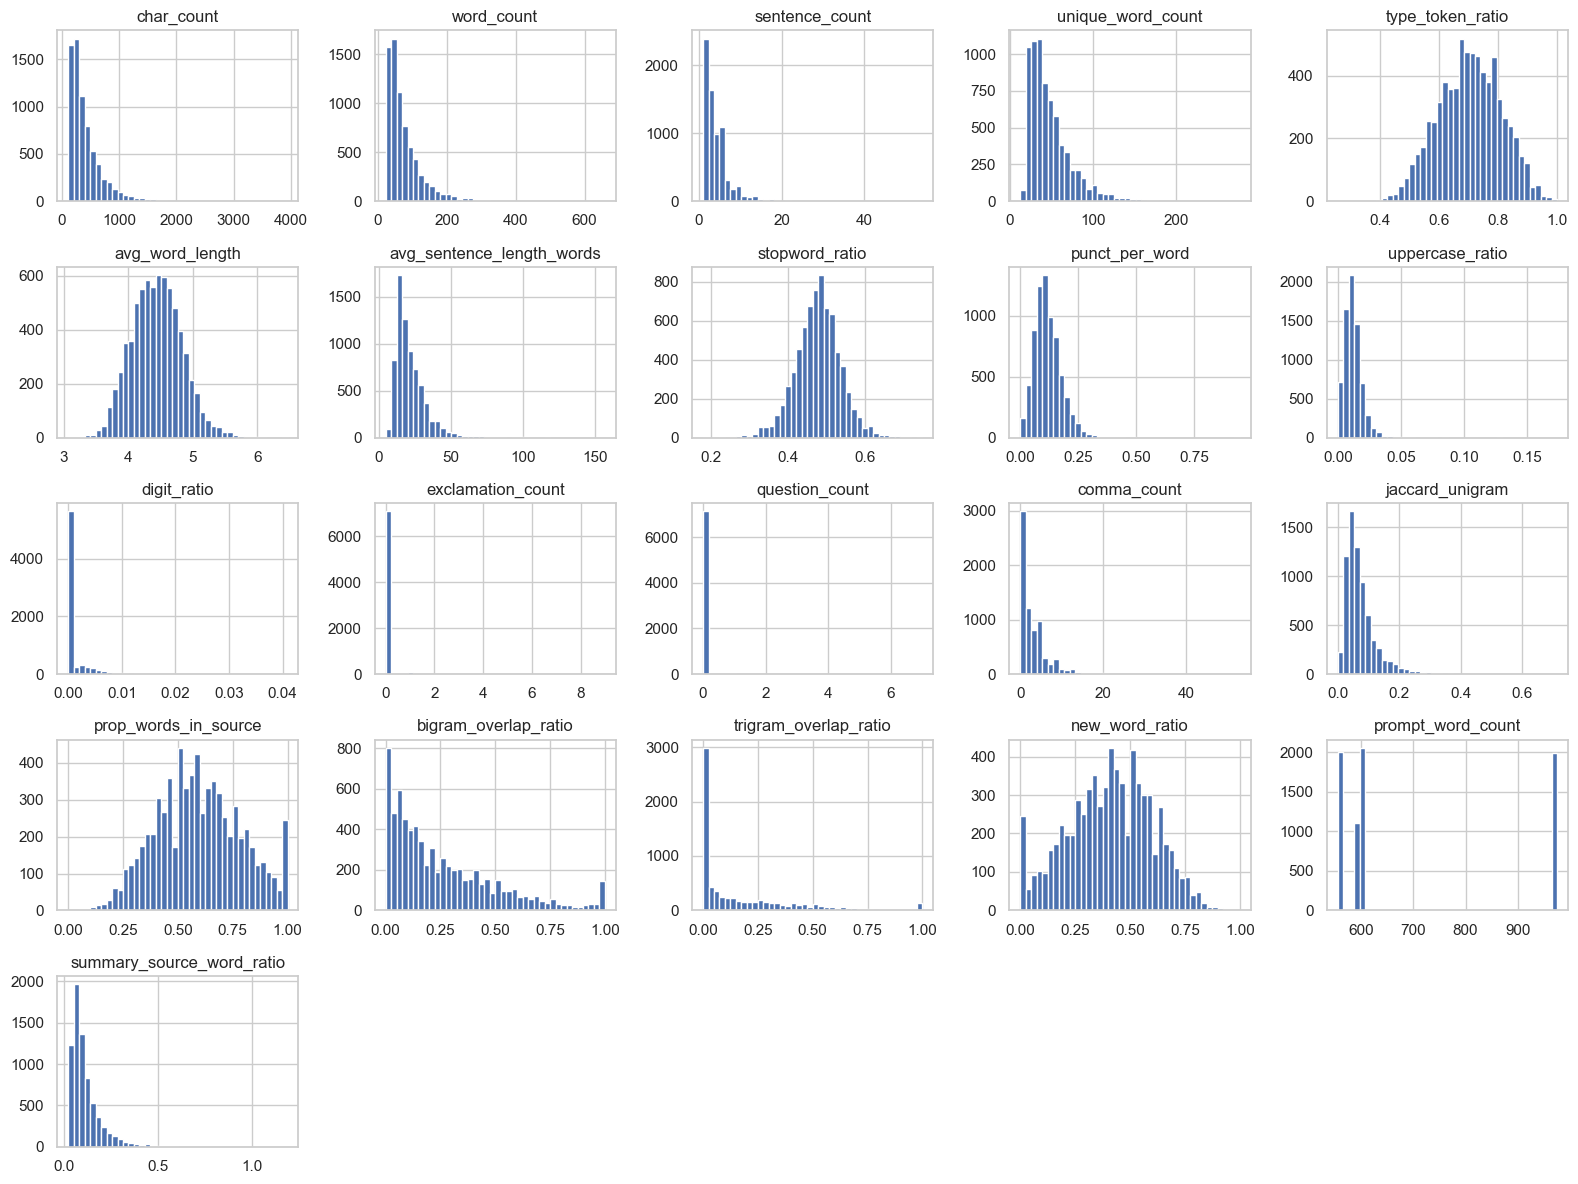

In [17]:
feat[eu.NUMERIC_FEATURES].hist(figsize=(16, 12), bins=40)
savefig('hist_features')
plt.show()

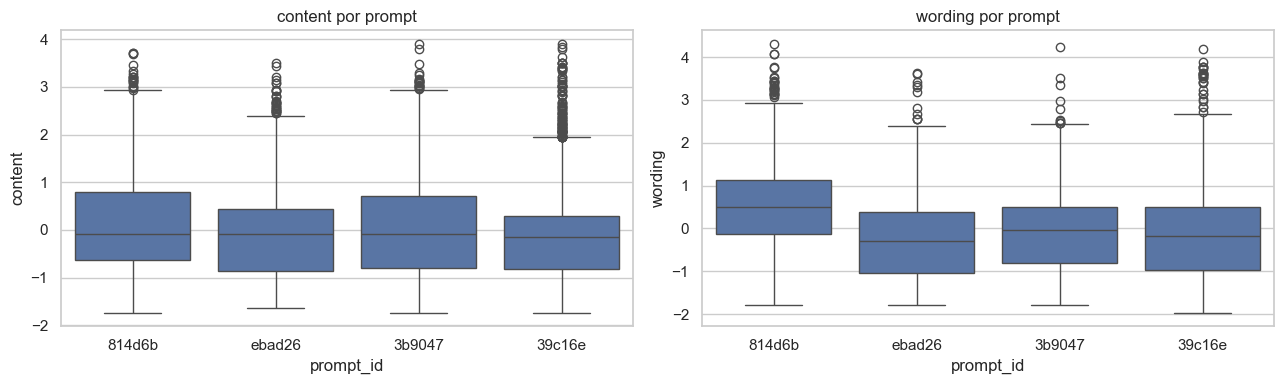

content               wording              
             mean median    std    mean median    std
prompt_id                                            
39c16e     -0.095 -0.157  0.970  -0.141 -0.169  1.056
3b9047      0.050 -0.094  1.106  -0.069 -0.045  0.953
814d6b      0.150 -0.094  1.124   0.519  0.504  1.108
ebad26     -0.088 -0.094  0.990  -0.299 -0.284  0.930

In [18]:
# Cruce categórica x numérica: content y wording por prompt
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for a, col in zip(ax, eu.TARGETS):
    sns.boxplot(data=feat, x='prompt_id', y=col, ax=a)
    a.set_title(f'{col} por prompt')
savefig('box_targets_por_prompt')
plt.show()

feat.groupby('prompt_id')[eu.TARGETS].agg(['mean', 'median', 'std']).round(3)

#### Boxplots por prompt

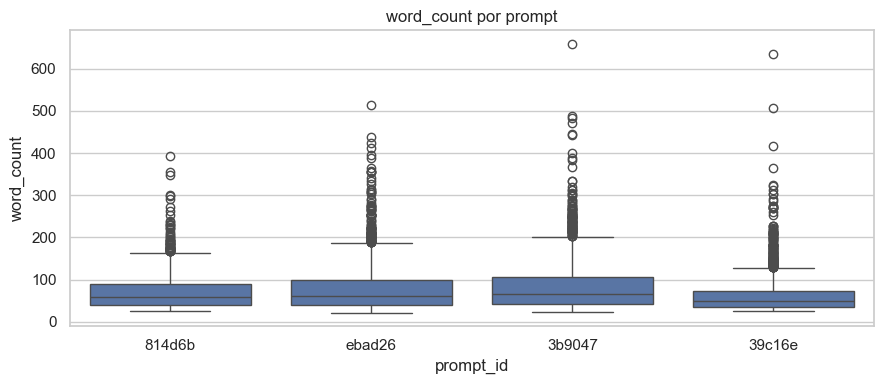

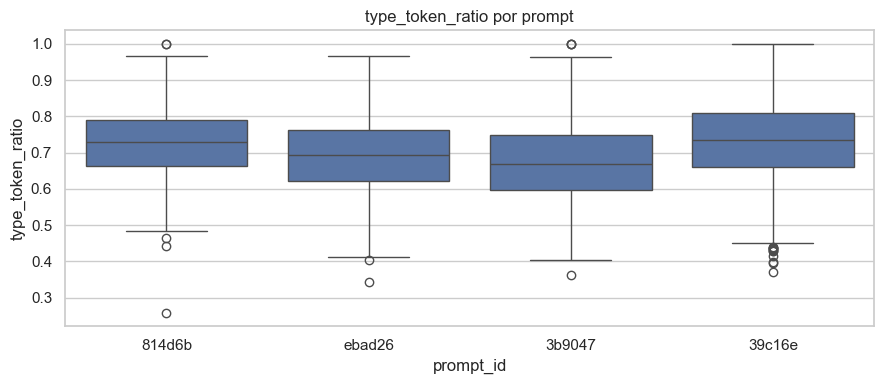

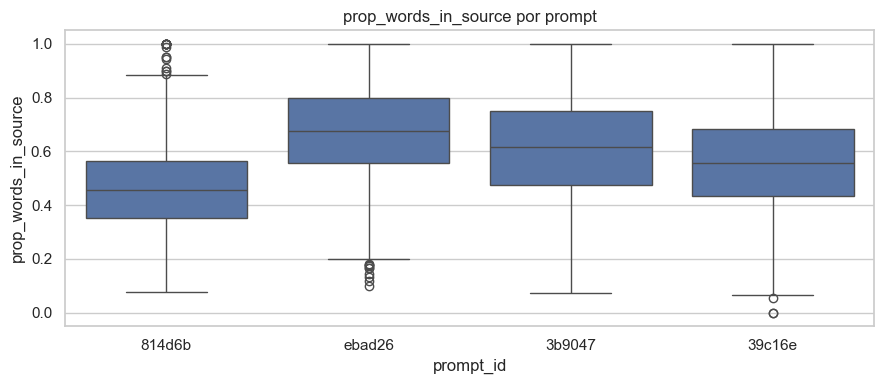

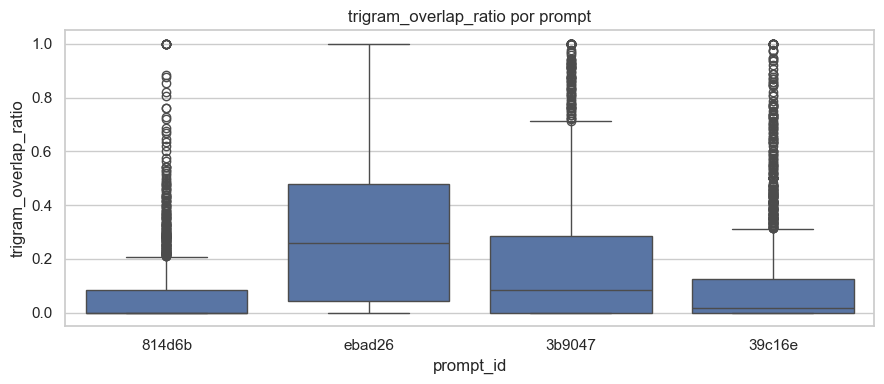

In [19]:
for col in ['word_count', 'type_token_ratio', 'prop_words_in_source', 'trigram_overlap_ratio']:
    plt.figure(figsize=(9, 4))
    sns.boxplot(data=feat, x='prompt_id', y=col)
    plt.title(f'{col} por prompt')
    savefig(f'box_{col}')
    plt.show()

In [20]:
# Regla IQR para cuantificar outliers de cada característica
def iqr_outliers(s):
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).sum(), lo, hi

pd.DataFrame(
    {c: iqr_outliers(feat[c]) for c in eu.NUMERIC_FEATURES},
    index=['n_outliers', 'limite_inf', 'limite_sup']
).T.round(3)

,n_outliers,limite_inf,limite_sup
char_count,424.0,-229.000,955.000
word_count,399.0,-40.500,171.500
sentence_count,432.0,-2.500,9.500
unique_word_count,311.0,-13.500,102.500
type_token_ratio,4.0,0.396,1.013
avg_word_length,63.0,3.373,5.489
avg_sentence_length_words,276.0,-4.250,44.950
stopword_ratio,169.0,0.334,0.622
punct_per_word,141.0,-0.032,0.258
uppercase_ratio,225.0,-0.005,0.028


### Correlaciones con las variables objetivo

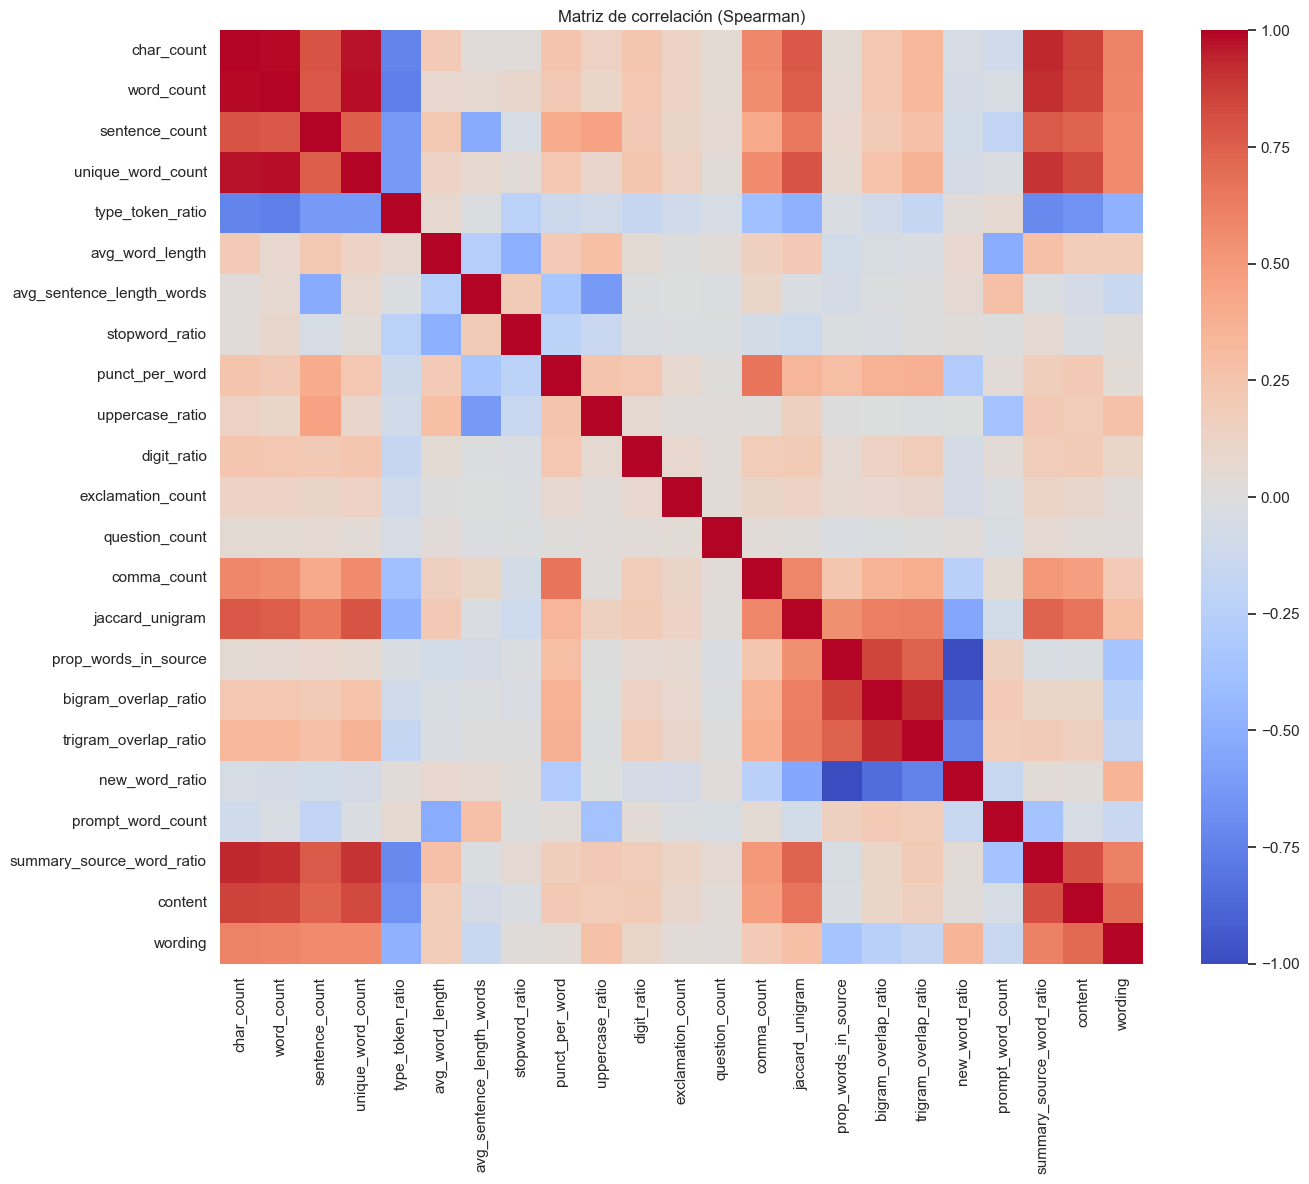

,content,wording
type_token_ratio,-0.659,-0.487
avg_sentence_length_words,-0.063,-0.138
prompt_word_count,-0.049,-0.143
prop_words_in_source,-0.025,-0.354
stopword_ratio,-0.024,0.017
new_word_ratio,0.025,0.354
question_count,0.032,0.030
exclamation_count,0.092,0.036
bigram_overlap_ratio,0.102,-0.245
trigram_overlap_ratio,0.162,-0.174


In [21]:
corr = feat[eu.NUMERIC_FEATURES + eu.TARGETS].corr(method='spearman')
plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Matriz de correlación (Spearman)')
savefig('corr_heatmap')
plt.show()

corr[eu.TARGETS].drop(eu.TARGETS).sort_values('content').round(3)

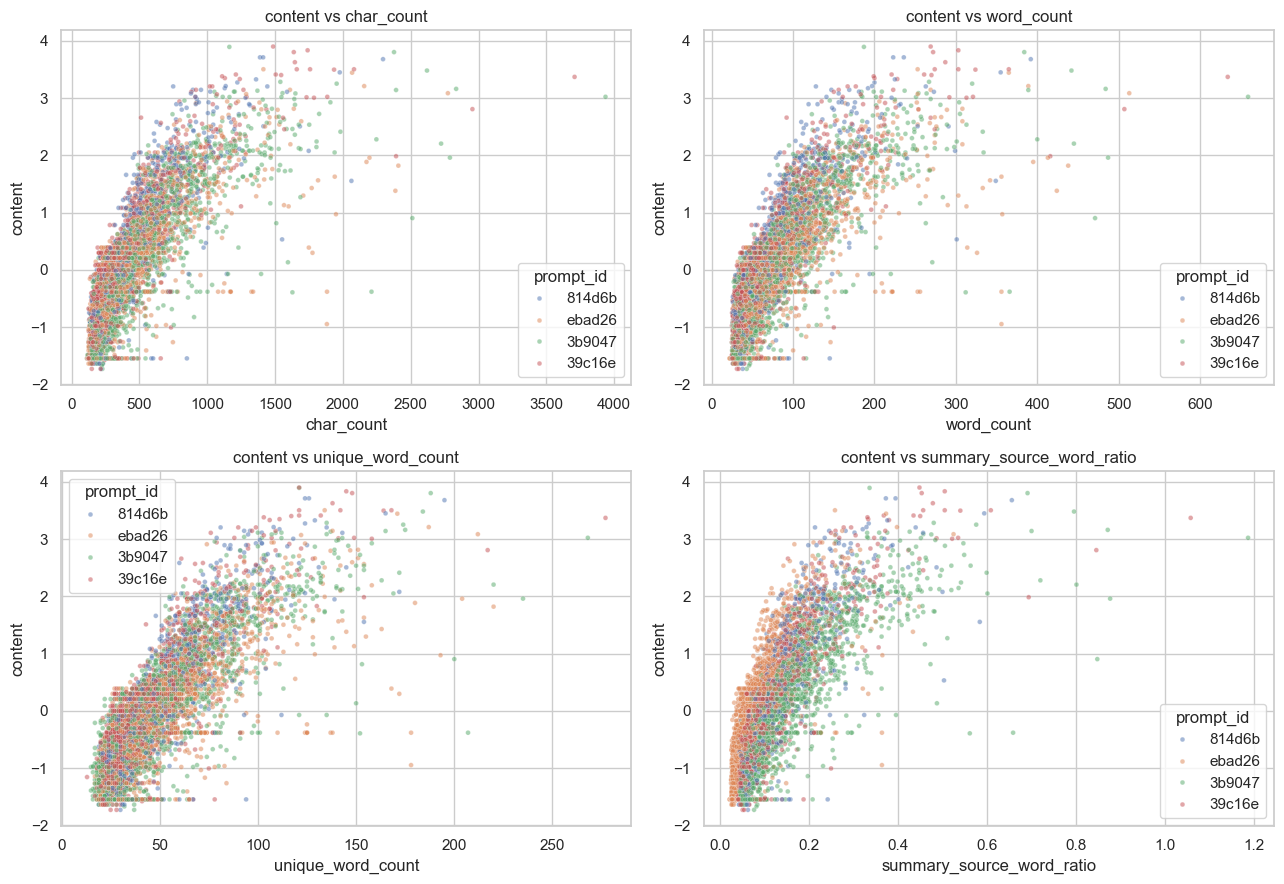

In [22]:
# Scatter de las señales más correlacionadas con 'content'
top = corr['content'].drop(eu.TARGETS).abs().sort_values(ascending=False).head(4).index
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
for a, col in zip(ax.ravel(), top):
    sns.scatterplot(data=feat, x=col, y='content', hue='prompt_id', s=12, alpha=.5, ax=a)
    a.set_title(f'content vs {col}')
savefig('scatter_top_content')
plt.show()

In [23]:
# ¿El solapamiento con la fuente penaliza 'wording'? (copiar y pegar)
feat['overlap_bin'] = pd.qcut(feat['prop_words_in_source'], 5, duplicates='drop')
feat.groupby('overlap_bin', observed=True)[['content', 'wording', 'word_count', 'trigram_overlap_ratio']].mean().round(3)

,content,wording,word_count,trigram_overlap_ratio
overlap_bin,,,,
"(-0.001, 0.421]",-0.178,0.239,65.737,0.008
"(0.421, 0.536]",0.101,0.272,73.683,0.047
"(0.536, 0.64]",0.168,0.117,78.423,0.109
"(0.64, 0.765]",0.156,-0.143,81.771,0.219
"(0.765, 1.0]",-0.322,-0.805,74.554,0.517


### Valores faltantes

In [24]:
miss = pd.concat([
    summaries_train.isna().sum().rename('summaries_train'),
    prompts_train.isna().sum().rename('prompts_train'),
], axis=1)
miss

,summaries_train,prompts_train
student_id,0.0,NaN
prompt_id,0.0,0.0
text,0.0,NaN
content,0.0,NaN
wording,0.0,NaN
prompt_question,NaN,0.0
prompt_title,NaN,0.0
prompt_text,NaN,0.0


## Conclusiones

- `content` y `wording` están correlacionadas (Pearson ≈ 0.75) pero miden aspectos distintos.
- La longitud del resumen es la señal más fuerte para ambas puntuaciones.
- El solapamiento alto con el texto fuente (copiar y pegar) baja sobre todo `wording`.
- `type_token_ratio` correlaciona negativo, pero es un efecto de la longitud.
- Hay diferencias de puntuación entre prompts → validar con GroupKFold por `prompt_id`.
- Los outliers de longitud son casos reales (transcripciones o respuestas mínimas), no errores.

In [25]:
# Exportar la tabla de características para reutilizarla en modelado
export_cols = [c for c in feat.columns if c != 'overlap_bin']
feat[export_cols].to_parquet(DATA_DIR / 'features_train.parquet', index=False)
print('Guardado como features_train.parquet')

Guardado como features_train.parquet
